
--- Result for: frame_00000.jpg ---
Mean:      116.01 -> 117.83
Std Dev:   32.66 -> 34.76
Sharpness: 236.12 -> 520.50


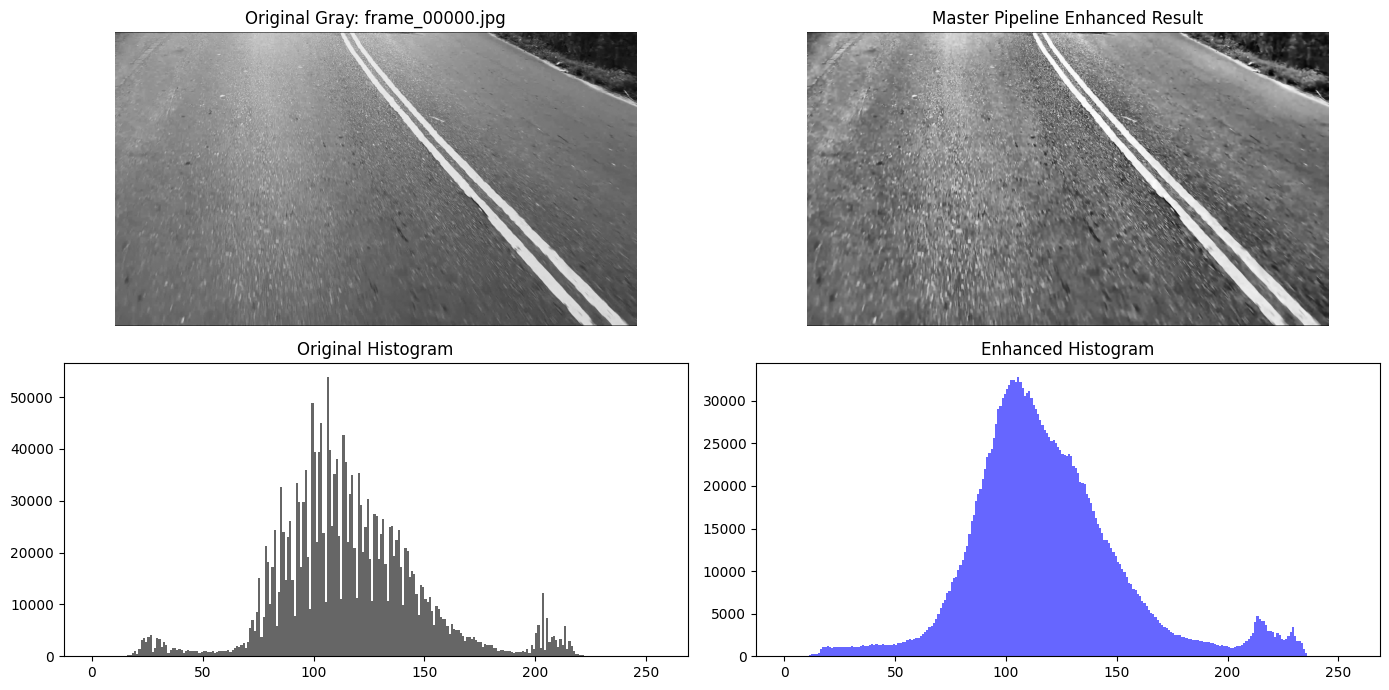


--- Result for: frame_00050.jpg ---
Mean:      117.21 -> 119.83
Std Dev:   33.32 -> 35.19
Sharpness: 194.05 -> 456.25


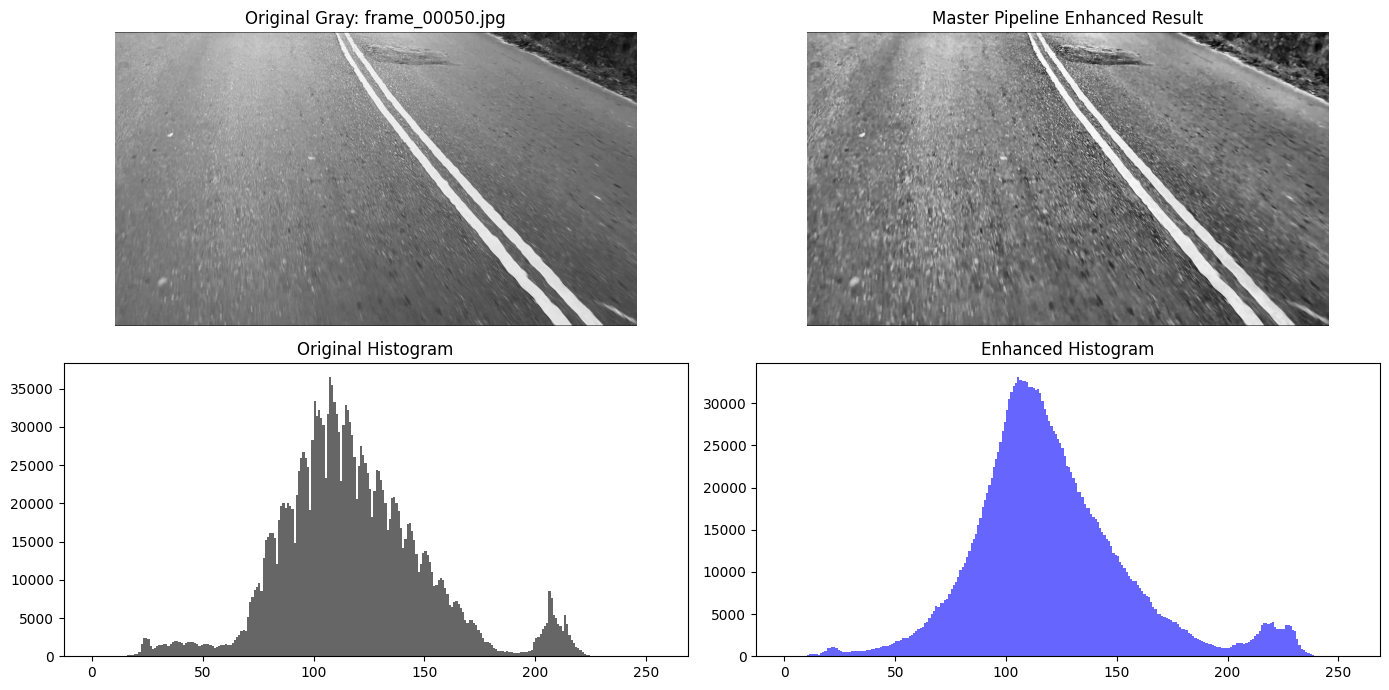


--- Result for: frame_00100.jpg ---
Mean:      119.01 -> 121.31
Std Dev:   32.10 -> 33.68
Sharpness: 172.33 -> 373.97


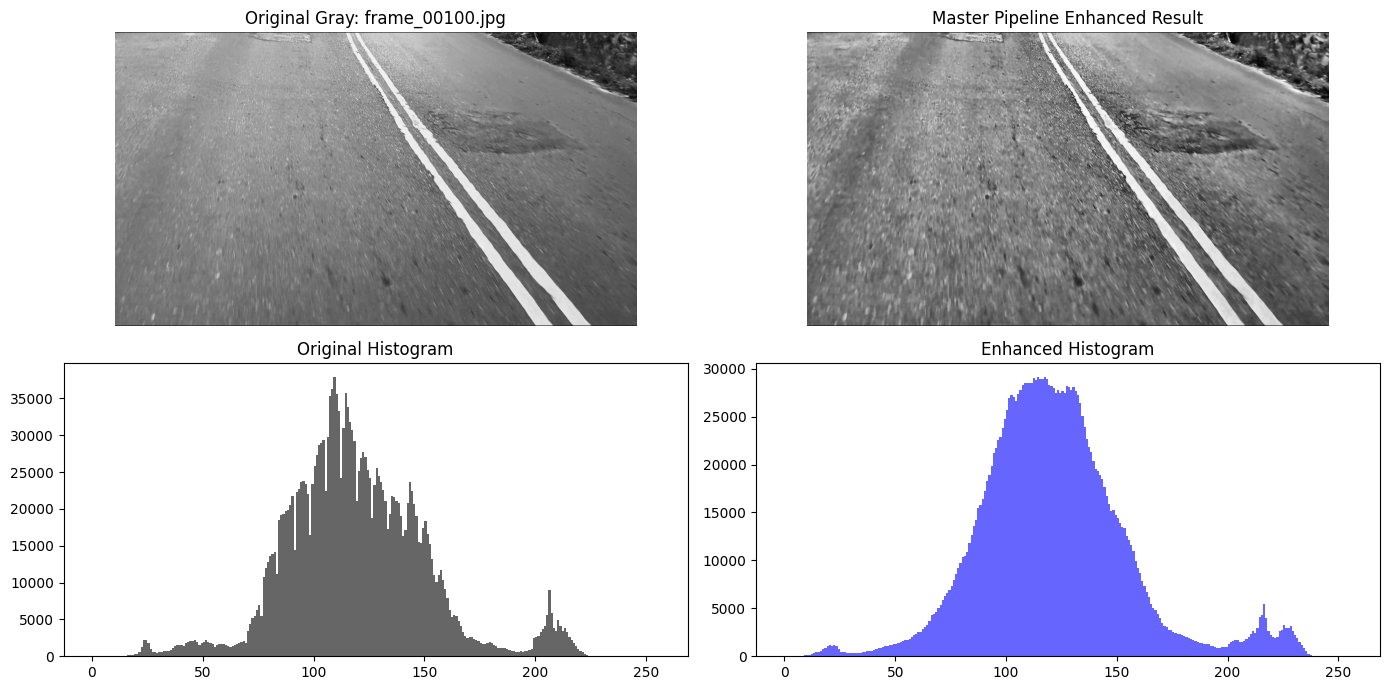

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

input_dir = 'extract_frame/'
test_frames = ["frame_00000.jpg", "frame_00050.jpg", "frame_00100.jpg"]

def compute_metrics(original, enhanced):
    mean_orig, mean_enh = np.mean(original), np.mean(enhanced)
    std_orig, std_enh = np.std(original), np.std(enhanced)
    sharp_orig = cv2.Laplacian(original, cv2.CV_64F).var()
    sharp_enh = cv2.Laplacian(enhanced, cv2.CV_64F).var()
    return mean_orig, mean_enh, std_orig, std_enh, sharp_orig, sharp_enh

def master_pipeline_enhance(gray):
    h, w = gray.shape[:2]
    enhanced = gray.copy()
    
    mean_val = np.mean(gray)       
    std_val = np.std(gray)         
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var() 

    if mean_val < 90 or std_val < 40:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(enhanced)

    k_size = int(w * 0.005)
    k_size = k_size + 1 if k_size % 2 == 0 else k_size 
    k_size = max(3, k_size) 

    enhanced = cv2.bilateralFilter(enhanced, d=k_size, sigmaColor=25, sigmaSpace=25)

    if sharpness < 50:
        blur = cv2.GaussianBlur(enhanced, (3,3), 0)
        enhanced = cv2.addWeighted(enhanced, 1.5, blur, -0.5, 0)  

    return enhanced

for frame_name in test_frames:
    img_path = os.path.join(input_dir, frame_name)
    img = cv2.imread(img_path)
    
    if img is None:
        print(f"Frame {frame_name} not found in {input_dir}!")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    enhanced = master_pipeline_enhance(gray)

    m_o, m_e, s_o, s_e, sh_o, sh_e = compute_metrics(gray, enhanced)
    
    print(f"\n--- Result for: {frame_name} ---")
    print(f"Mean:      {m_o:.2f} -> {m_e:.2f}")
    print(f"Std Dev:   {s_o:.2f} -> {s_e:.2f}")
    print(f"Sharpness: {sh_o:.2f} -> {sh_e:.2f}")
    
    plt.figure(figsize=(14, 7))

    # Top Left: Original
    plt.subplot(2, 2, 1)
    plt.imshow(gray, cmap='gray')
    plt.title(f"Original Gray: {frame_name}")
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(enhanced, cmap='gray')
    plt.title("Master Pipeline Enhanced Result")
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.hist(gray.ravel(), bins=256, range=(0, 256), color='black', alpha=0.6)
    plt.title("Original Histogram")

    plt.subplot(2, 2, 4)
    plt.hist(enhanced.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.6)
    plt.title("Enhanced Histogram")

    plt.tight_layout()
    plt.show()